In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve project root from the notebooks directory
project_root = Path().resolve().parent
data_raw_dir = project_root / "data" / "raw"

# Load summary DataFrame and master path tensor
df_results_path = data_raw_dir / "synthetic_4d_monte_carlo_results.parquet"
tensor_path = data_raw_dir / "master_path_tensor.npy"

df_results = pd.read_parquet(df_results_path)
master_tensor = np.load(tensor_path)

print("--- Artifact Loading Verification ---")
print(f"Summary DataFrame Shape: {df_results.shape}")
print(f"Master Tensor Shape:     {master_tensor.shape}")
print(f"Tensor Data Type:        {master_tensor.dtype}")
print(f"Memory Footprint:        {master_tensor.nbytes / (1024**2):.2f} MB")

display(df_results.head(3))

--- Artifact Loading Verification ---
Summary DataFrame Shape: (81, 9)
Master Tensor Shape:     (81, 5000, 90)
Tensor Data Type:        float32
Memory Footprint:        139.05 MB


,Node_Index,Institution_Key,Volatility,Tail_Tier,Asymmetry,Shock_Severity,Mean_Max_DD,P95_Max_DD,Distress_Probability
0,0,Vol-Low_Tail-Fat_Asym-Low_Shock-Mild,Vol-Low,Tail-Fat,Asym-Low,Shock-Mild,-0.364450,-0.500781,0.3068
1,1,Vol-Low_Tail-Fat_Asym-Low_Shock-Mod,Vol-Low,Tail-Fat,Asym-Low,Shock-Mod,-0.366569,-0.511026,0.3234
2,2,Vol-Low_Tail-Fat_Asym-Low_Shock-Sev,Vol-Low,Tail-Fat,Asym-Low,Shock-Sev,-0.364910,-0.504953,0.3178


In [2]:
# Select the first node (Index 0) corresponding to grid[0]
node_0_key = df_results.loc[0, "Institution_Key"]
node_0_paths = master_tensor[0]  # Shape: (5000, 90)

print(f"Inspecting Node: {node_0_key}")
print(f"Node Path Tensor Shape: {node_0_paths.shape}")

# Calculate path-dependent 90-day Value-at-Risk (VaR) or Drawdowns directly from tensor
terminal_prices = node_0_paths[:, -1]
p5_terminal = np.percentile(terminal_prices, 5)
print(f"5th Percentile Terminal Price (Node 0): {p5_terminal:.2f}")

Inspecting Node: Vol-Low_Tail-Fat_Asym-Low_Shock-Mild
Node Path Tensor Shape: (5000, 90)
5th Percentile Terminal Price (Node 0): 55.07


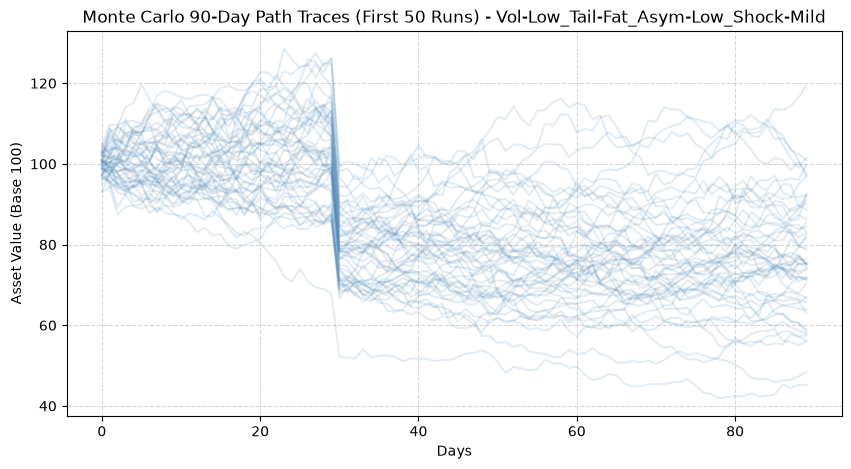

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Plot first 50 paths out of 5000 for the first node
plt.plot(node_0_paths[:50].T, color="steelblue", alpha=0.15)
plt.title(f"Monte Carlo 90-Day Path Traces (First 50 Runs) - {node_0_key}")
plt.xlabel("Days")
plt.ylabel("Asset Value (Base 100)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()